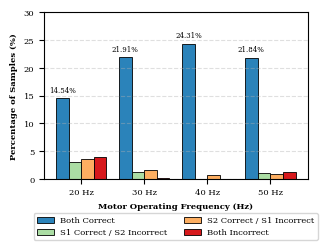

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Настройки стиля IEEE (Serif шрифты)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 6

# Данные
frequencies = ['20 Hz', '30 Hz', '40 Hz', '50 Hz']
data = {
    'Both Correct': [14.54, 21.91, 24.31, 21.84],
    'S1 Correct / S2 Incorrect': [3.01, 1.31, 0.02, 1.06],
    'S2 Correct / S1 Incorrect': [3.52, 1.58, 0.66, 0.89],
    'Both Incorrect': [3.93, 0.20, 0.01, 1.22]
}

x = np.arange(len(frequencies))
width = 0.2 

fig, ax = plt.subplots(figsize=(3.299213, 2.53937))
colors = ['#2b83ba', '#abdda4', '#fdae61', '#d7191c'] # Академическая палитра

# Отрисовка столбцов
for i, (label, values) in enumerate(data.items()):
    offset = (i - 1.5) * width
    rects = ax.bar(x + offset, values, width, label=label, color=colors[i], edgecolor='black', linewidth=0.6)
    
    # Добавляем подписи только для значений > 5%, чтобы избежать наложения
    for rect in rects:
        height = rect.get_height()
        if height > 5.0:
            ax.annotate(f'{height}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=5)

# Оформление осей и заголовка
ax.set_ylabel('Percentage of Samples (%)', fontweight='bold')
ax.set_xlabel('Motor Operating Frequency (Hz)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(frequencies)
ax.set_ylim(0, 30)

# Легенда снизу (в 2 колонки)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True, fontsize=6)

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# Сохранение для статьи
# plt.savefig('sensor_performance.pdf', format='pdf', bbox_inches='tight')
plt.savefig("sensor_performance.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()
